# Ekstraklasa 2025/26 - Team Analytics

Sofascore xG and per-match team metrics across all 18 clubs. Companion to
`01_three_clubs_analysis.ipynb` (FBref counting stats).

## 1. Setup and load

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import poisson
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

DRIVE = '/content/drive/MyDrive/ekstraklasa-2025-26'
SOFA = f'{DRIVE}/sofascore'
FBREF = f'{DRIVE}/fbref'
FIG = '/content/figures'
os.makedirs(FIG, exist_ok=True)

JAGA = '#1e5fb4'
LECH = '#0a6b3a'
LEGIA = '#a02828'
GREY = '#9aa0a6'

plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
})

Mounted at /content/drive


In [3]:
matches = pd.read_csv(f'{SOFA}/sofascore_matches.csv')
shots = pd.read_csv(f'{SOFA}/sofascore_shots.csv')
player_match = pd.read_csv(f'{SOFA}/sofascore_player_match.csv')
player_master = pd.read_csv(f'{SOFA}/player_master.csv')
standings = pd.read_csv(f'{FBREF}/league_standings.csv')

matches['date'] = pd.to_datetime(matches['date'])

cols = ['match_id', 'round', 'date', 'team', 'opp', 'gf', 'ga', 'xg', 'xga',
        'possession', 'shots', 'opp_shots', 'sot', 'big_chances', 'corners',
        'passes', 'acc_passes', 'touches_in_box', 'final_third_entries',
        'recoveries', 'goals_prevented']

home = matches.rename(columns={
    'home_team': 'team', 'away_team': 'opp',
    'home_score': 'gf', 'away_score': 'ga',
    'home_xg': 'xg', 'away_xg': 'xga',
    'home_possession': 'possession',
    'home_shots': 'shots', 'away_shots': 'opp_shots',
    'home_shots_on_target': 'sot',
    'home_big_chances': 'big_chances',
    'home_corners': 'corners',
    'home_passes': 'passes', 'home_accurate_passes': 'acc_passes',
    'home_touches_in_box': 'touches_in_box',
    'home_final_third_entries': 'final_third_entries',
    'home_recoveries': 'recoveries',
    'home_goals_prevented': 'goals_prevented',
})[cols].assign(venue='H')

away = matches.rename(columns={
    'away_team': 'team', 'home_team': 'opp',
    'away_score': 'gf', 'home_score': 'ga',
    'away_xg': 'xg', 'home_xg': 'xga',
    'away_possession': 'possession',
    'away_shots': 'shots', 'home_shots': 'opp_shots',
    'away_shots_on_target': 'sot',
    'away_big_chances': 'big_chances',
    'away_corners': 'corners',
    'away_passes': 'passes', 'away_accurate_passes': 'acc_passes',
    'away_touches_in_box': 'touches_in_box',
    'away_final_third_entries': 'final_third_entries',
    'away_recoveries': 'recoveries',
    'away_goals_prevented': 'goals_prevented',
})[cols].assign(venue='A')

team_match = pd.concat([home, away], ignore_index=True).sort_values(['date', 'match_id'])
team_match['result'] = np.where(team_match['gf'] > team_match['ga'], 'W',
                         np.where(team_match['gf'] < team_match['ga'], 'L', 'D'))
team_match['pts'] = team_match['result'].map({'W': 3, 'D': 1, 'L': 0})
team_match = team_match.reset_index(drop=True)

print(matches.shape, shots.shape, player_match.shape, player_master.shape, standings.shape)
print('team_match:', team_match.shape)
team_match.head()

(306, 49) (8432, 17) (13206, 43) (625, 56) (18, 15)
team_match: (612, 24)


,match_id,round,date,team,opp,gf,ga,xg,xga,possession,...,corners,passes,acc_passes,touches_in_box,final_third_entries,recoveries,goals_prevented,venue,result,pts
0,13981759,1,2025-07-18,Jagiellonia Białystok,Bruk-Bet Termalica Nieciecza,0,4,0.89,2.47,64,...,3,543,469,35,73,57,-0.8090,H,L,0
1,13981759,1,2025-07-18,Bruk-Bet Termalica Nieciecza,Jagiellonia Białystok,4,0,2.47,0.89,36,...,8,311,226,23,49,56,0.2532,A,W,3
2,13981761,1,2025-07-18,Lech Poznań,Cracovia,1,4,1.43,0.73,75,...,5,638,572,16,90,31,-1.6238,H,L,0
3,13981761,1,2025-07-18,Cracovia,Lech Poznań,4,1,0.73,1.43,25,...,0,222,153,8,31,31,-0.0992,A,W,3
4,13981750,1,2025-07-19,Widzew Łódź,Zagłębie Lubin,1,0,1.06,0.67,53,...,8,349,283,34,58,34,0.1240,H,W,3


## 2. League style clustering

Per-match averages across 10 style features, standardised, KMeans k=4,
projected to 2D with PCA. Clusters labelled by reading each centroid.

In [7]:
km = KMeans(n_clusters=4, n_init=30, random_state=42).fit(X)
team_stats['cluster'] = km.labels_

pca = PCA(n_components=2, random_state=42)
xy = pca.fit_transform(X)
team_stats['pc1'] = xy[:, 0]
team_stats['pc2'] = xy[:, 1]

print(f'PCA explained variance: {pca.explained_variance_ratio_.sum():.1%}')
print()
print(team_stats[['team', 'cluster', 'xg', 'xga', 'possession', 'xg_per_shot', 'recoveries']]
      .sort_values(['cluster', 'xg'], ascending=[True, False])
      .to_string(index=False))

PCA explained variance: 68.0%

                        team  cluster       xg      xga  possession  xg_per_shot  recoveries
                 Lech Poznań        0 1.896176 1.201765   57.588235     0.108718   44.588235
            KS Lechia Gdańsk        0 1.739706 1.492353   50.647059     0.120468   49.647059
           Raków Częstochowa        0 1.623529 1.272941   53.911765     0.116211   46.970588
              Pogoń Szczecin        0 1.568529 1.585588   52.029412     0.108174   43.235294
               Górnik Zabrze        1 1.462647 1.238529   51.529412     0.091081   45.588235
              Legia Warszawa        1 1.433529 1.025000   52.441176     0.099267   47.205882
                    Cracovia        1 1.288235 1.107059   50.500000     0.101389   44.705882
                 Widzew Łódź        1 1.204118 1.148235   48.852941     0.093045   46.147059
                GKS Katowice        2 1.343235 1.427647   46.323529     0.105230   44.205882
              Radomiak Radom        2 1

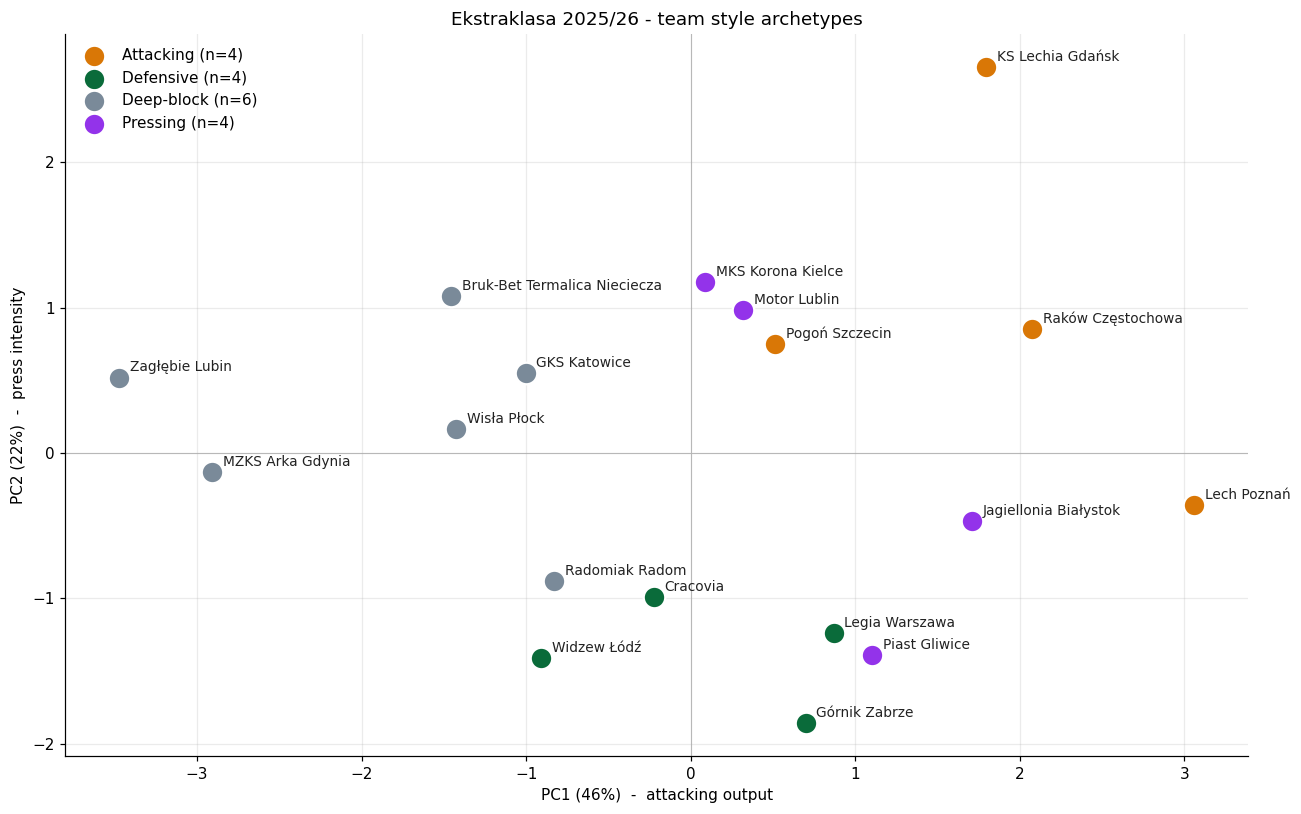

In [10]:
cluster_labels = {
    0: 'Attacking',
    1: 'Defensive',
    2: 'Deep-block',
    3: 'Pressing',
}
cluster_colors = {0: '#d97706', 1: '#0a6b3a', 2: '#7a8a99', 3: '#9333ea'}

fig, ax = plt.subplots(figsize=(12, 7.5))
for c in sorted(team_stats['cluster'].unique()):
    sub = team_stats[team_stats['cluster'] == c]
    ax.scatter(sub['pc1'], sub['pc2'], s=200, c=cluster_colors[c],
               edgecolor='white', linewidth=1.5,
               label=f'{cluster_labels[c]} (n={len(sub)})', zorder=3)

for _, r in team_stats.iterrows():
    ax.annotate(r['team'], (r['pc1'], r['pc2']),
                xytext=(7, 4), textcoords='offset points',
                fontsize=9, color='#222')

ax.axhline(0, color='#bbb', lw=0.7, zorder=1)
ax.axvline(0, color='#bbb', lw=0.7, zorder=1)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%})  -  attacking output')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%})  -  press intensity')
ax.set_title('Ekstraklasa 2025/26 - team style archetypes')
ax.legend(loc='upper left', frameon=False, fontsize=10)
plt.tight_layout()
plt.savefig(f'{FIG}/02_style_clusters.png')
plt.show()

## 3. Tactical fingerprint radar

Six Sofascore metrics, min-max normalised across all 18 clubs, plotted against
the league average. Defence stored as 1/xGA so higher means better on every
axis.

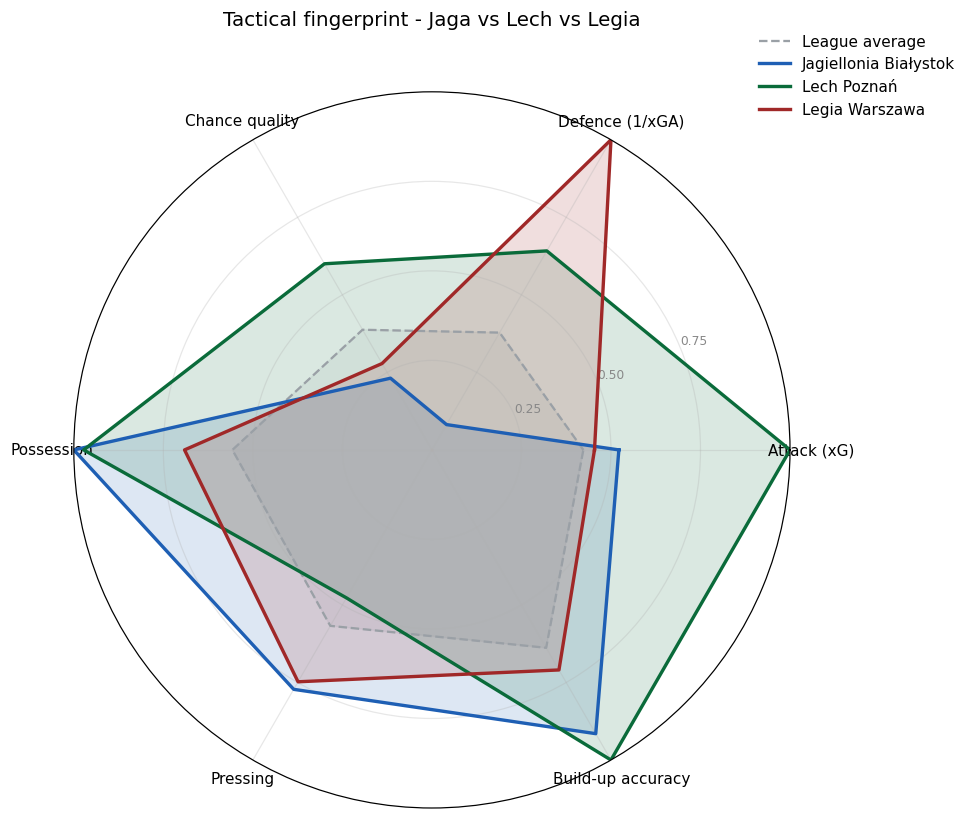

In [11]:
radar_metrics = {
    'Attack (xG)':         team_stats['xg'],
    'Defence (1/xGA)':     1 / team_stats['xga'],
    'Chance quality':      team_stats['xg_per_shot'],
    'Possession':          team_stats['possession'],
    'Pressing':            team_stats['recoveries'],
    'Build-up accuracy':   team_stats['pass_acc'],
}
radar_df = pd.DataFrame(radar_metrics)
radar_df.index = team_stats['team']

# Min-max to 0-1 across the league.
radar_norm = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min())

focus = ['Jagiellonia Białystok', 'Lech Poznań', 'Legia Warszawa']
colors = {'Jagiellonia Białystok': JAGA, 'Lech Poznań': LECH, 'Legia Warszawa': LEGIA}

labels = list(radar_norm.columns)
N = len(labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

# League average baseline.
avg = radar_norm.mean().tolist()
avg += avg[:1]
ax.plot(angles, avg, color=GREY, lw=1.5, ls='--', label='League average')
ax.fill(angles, avg, color=GREY, alpha=0.1)

for team in focus:
    vals = radar_norm.loc[team].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, color=colors[team], lw=2.2, label=team)
    ax.fill(angles, vals, color=colors[team], alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10)
ax.set_yticks([0.25, 0.5, 0.75])
ax.set_yticklabels(['0.25', '0.50', '0.75'], color='#888', fontsize=8)
ax.set_ylim(0, 1)
ax.set_title('Tactical fingerprint - Jaga vs Lech vs Legia', y=1.08, fontsize=13)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1), frameon=False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG}/03_radar.png')
plt.show()

## 4. xPts - actual vs expected points

Per-match expected points via independent Poisson with xG as the rate.
Outer product gives the goal-count joint distribution, then sum into
P(W), P(D), P(L) and weight 3 / 1 / 0. Sum across the season per team.

In [12]:
MAX_GOALS = 8

def match_xpts(xg_for, xg_against):
    p_for = poisson.pmf(np.arange(MAX_GOALS + 1), xg_for)
    p_against = poisson.pmf(np.arange(MAX_GOALS + 1), xg_against)
    joint = np.outer(p_for, p_against)
    p_win = np.tril(joint, -1).sum()
    p_draw = np.trace(joint)
    p_loss = np.triu(joint, 1).sum()
    return 3 * p_win + 1 * p_draw, p_win, p_draw, p_loss

xpts_vals = team_match.apply(lambda r: match_xpts(r['xg'], r['xga']), axis=1, result_type='expand')
xpts_vals.columns = ['xpts', 'p_win', 'p_draw', 'p_loss']
team_match = pd.concat([team_match.drop(columns=[c for c in xpts_vals.columns if c in team_match], errors='ignore'),
                        xpts_vals], axis=1)

season = team_match.groupby('team', as_index=False).agg(
    pts=('pts', 'sum'),
    xpts=('xpts', 'sum'),
    gf=('gf', 'sum'),
    ga=('ga', 'sum'),
    xg=('xg', 'sum'),
    xga=('xga', 'sum'),
)
season['diff'] = season['pts'] - season['xpts']
season = season.sort_values('diff', ascending=False).reset_index(drop=True)
print(season.to_string(index=False))

                        team  pts      xpts  gf  ga    xg   xga      diff
       Jagiellonia Białystok   56 44.260800  56  41 50.70 55.94 11.739200
              Zagłębie Lubin   48 40.483504  45  38 39.55 47.35  7.516496
                GKS Katowice   50 43.848876  51  45 45.67 48.54  6.151124
               Górnik Zabrze   56 50.044931  50  38 49.73 42.11  5.955069
                Motor Lublin   43 38.086862  46  53 43.01 59.12  4.913138
                 Wisła Płock   46 44.856031  34  38 42.56 45.54  1.143969
           Raków Częstochowa   55 54.474163  51  40 55.20 43.28  0.525837
            MZKS Arka Gdynia   36 35.507201  34  61 35.66 53.87  0.492799
              Radomiak Radom   44 44.222007  52  53 44.81 52.57 -0.222007
                 Lech Poznań   60 61.363495  62  45 64.47 40.86 -1.363495
              Pogoń Szczecin   45 47.158663  47  49 53.33 53.91 -2.158663
Bruk-Bet Termalica Nieciecza   34 39.291164  43  65 44.14 57.85 -5.291164
           MKS Korona Kielce   43 48.5

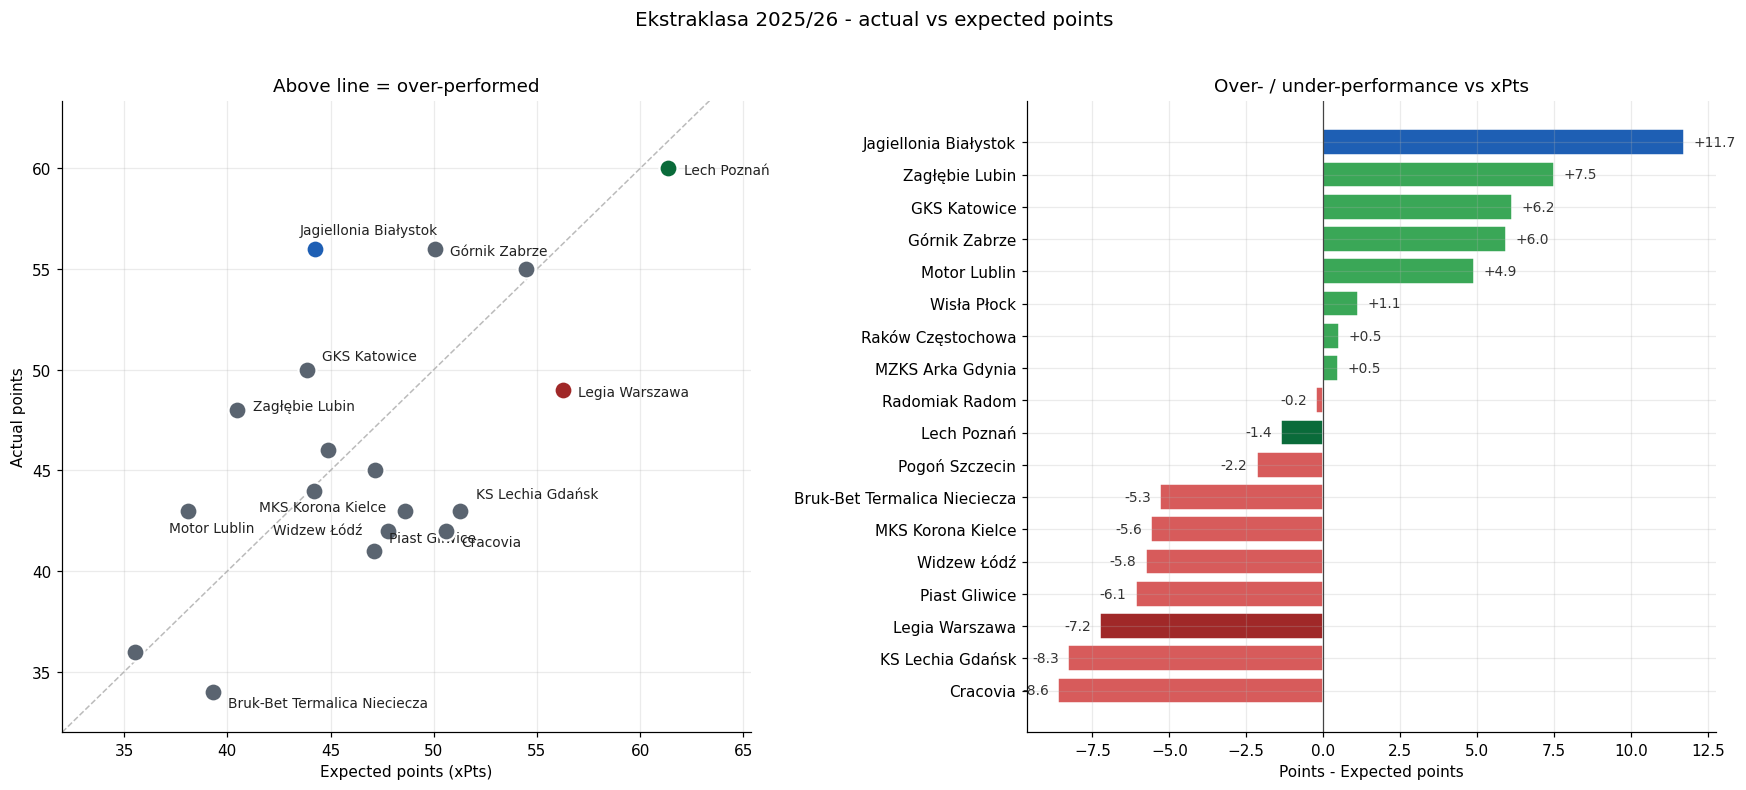

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [1, 1]})

ax = axes[0]
default_color = '#5a6470'
focus_colors = {'Jagiellonia Białystok': JAGA, 'Lech Poznań': LECH, 'Legia Warszawa': LEGIA}

offsets = {
    'Jagiellonia Białystok': (-10, 10),
    'Górnik Zabrze': (10, -4),
    'Lech Poznań': (10, -4),
    'Legia Warszawa': (10, -4),
    'GKS Katowice': (10, 6),
    'Zagłębie Lubin': (10, 0),
    'Motor Lublin': (-12, -14),
    'KS Lechia Gdańsk': (10, 8),
    'MKS Korona Kielce': (-95, 0),
    'Widzew Łódź': (-75, -2),
    'Cracovia': (10, -10),
    'Piast Gliwice': (10, 6),
    'Bruk-Bet Termalica Nieciecza': (10, -10),
}

for _, r in season.iterrows():
    c = focus_colors.get(r['team'], default_color)
    ax.scatter(r['xpts'], r['pts'], s=140, c=c, edgecolor='white', linewidth=1.5, zorder=3)
    if r['team'] in focus_colors or abs(r['diff']) > 4.5:
        dx, dy = offsets.get(r['team'], (8, 6))
        ax.annotate(r['team'], (r['xpts'], r['pts']),
                    xytext=(dx, dy), textcoords='offset points',
                    fontsize=9, color='#222')

lo = min(season['xpts'].min(), season['pts'].min()) - 2
hi = max(season['xpts'].max(), season['pts'].max()) + 2
ax.plot([lo, hi], [lo, hi], '--', color='#bbb', lw=1, zorder=1)
ax.set_xlim(lo, hi + 2)
ax.set_ylim(lo, hi)
ax.set_xlabel('Expected points (xPts)')
ax.set_ylabel('Actual points')
ax.set_title('Above line = over-performed')

ax = axes[1]
order = season.sort_values('diff', ascending=True)
bar_colors = [focus_colors.get(t, '#d75b5b' if d < 0 else '#3aa757')
              for t, d in zip(order['team'], order['diff'])]
ax.barh(order['team'], order['diff'], color=bar_colors, edgecolor='white')
ax.axvline(0, color='#444', lw=0.8)
for i, (t, d) in enumerate(zip(order['team'], order['diff'])):
    ax.text(d + (0.3 if d >= 0 else -0.3), i, f'{d:+.1f}',
            va='center', ha='left' if d >= 0 else 'right', fontsize=9, color='#333')
ax.set_xlabel('Points - Expected points')
ax.set_title('Over- / under-performance vs xPts')

plt.suptitle('Ekstraklasa 2025/26 - actual vs expected points', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIG}/04_xpts.png')
plt.show()

## 5. Cumulative xPts trajectory

Per matchweek cumulative actual points vs expected points. Where the lines
diverge is where the season ran hot or cold.

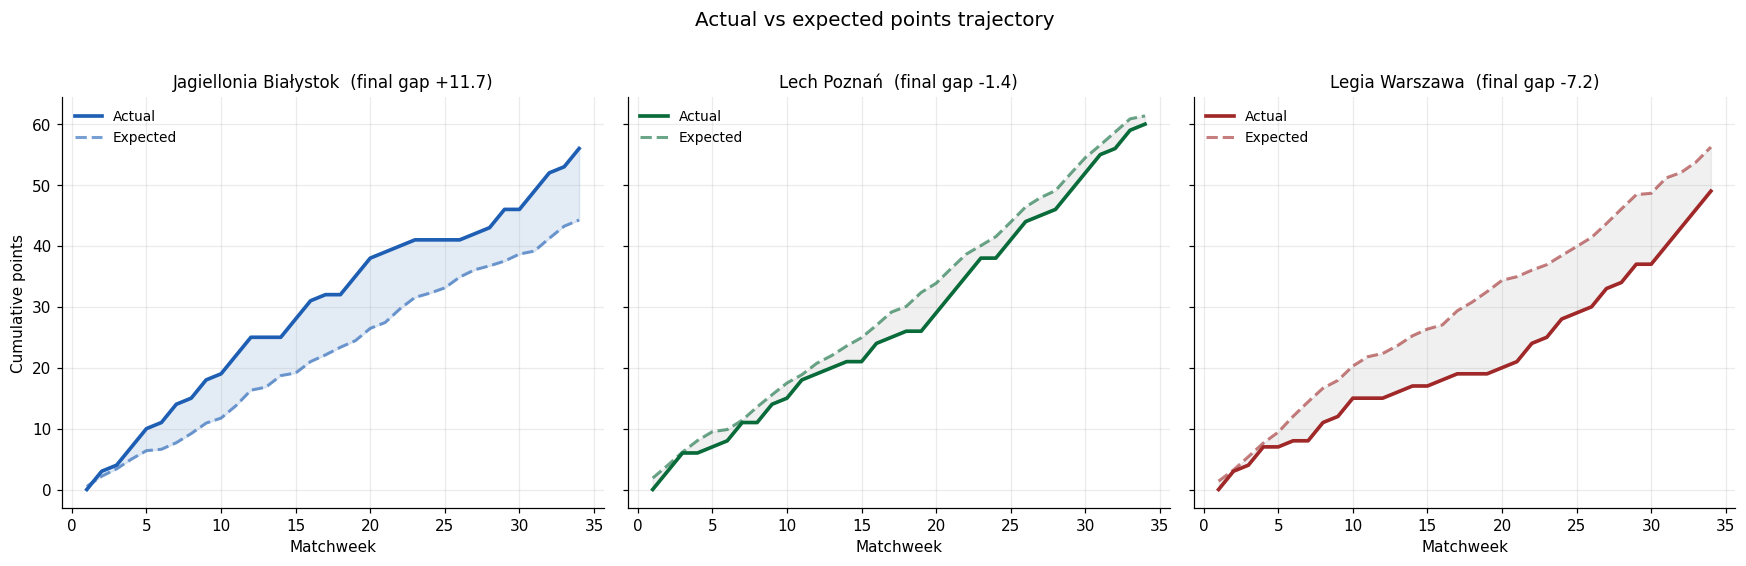

In [21]:
focus = ['Jagiellonia Białystok', 'Lech Poznań', 'Legia Warszawa']
colors = {
    'Jagiellonia Białystok': JAGA,
    'Lech Poznań': LECH,
    'Legia Warszawa': LEGIA,
}

traj = team_match[team_match['team'].isin(focus)].copy()
traj = traj.sort_values(['team', 'round'])
traj['cum_pts'] = traj.groupby('team')['pts'].cumsum()
traj['cum_xpts'] = traj.groupby('team')['xpts'].cumsum()

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, team in zip(axes, focus):
    sub = traj[traj['team'] == team]
    c = colors[team]
    ax.plot(sub['round'], sub['cum_pts'], color=c, lw=2.4, label='Actual')
    ax.plot(sub['round'], sub['cum_xpts'], color=c, lw=2, ls='--', alpha=0.6, label='Expected')
    ax.fill_between(sub['round'], sub['cum_pts'], sub['cum_xpts'],
                    where=sub['cum_pts'] >= sub['cum_xpts'],
                    color=c, alpha=0.12, interpolate=True)
    ax.fill_between(sub['round'], sub['cum_pts'], sub['cum_xpts'],
                    where=sub['cum_pts'] < sub['cum_xpts'],
                    color='#888', alpha=0.12, interpolate=True)
    final_diff = sub['cum_pts'].iloc[-1] - sub['cum_xpts'].iloc[-1]
    ax.set_title(f'{team}  (final gap {final_diff:+.1f})', fontsize=11)
    ax.legend(loc='upper left', frameon=False, fontsize=9)
    ax.set_xlabel('Matchweek')

axes[0].set_ylabel('Cumulative points')
plt.suptitle('Actual vs expected points trajectory', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIG}/05_xpts_trajectory.png')
plt.show()

In [ ]:
## 6. Over- and under-performance breakdown

Standings sorted by actual points, with expected position and the gap
decomposed into finishing (GF vs xG) and defending (GA vs xGA).
Goalkeeper over- / under-performance via Sofascore goals prevented
(sum of xGOT minus actual goals conceded).

In [23]:
table = season.copy()
table['MP'] = 34
table['gd'] = table['gf'] - table['ga']
table['xgd'] = table['xg'] - table['xga']
table['finishing'] = table['gf'] - table['xg']
table['defending'] = table['xga'] - table['ga']

table = table.sort_values(['pts', 'gd'], ascending=[False, False]).reset_index(drop=True)
table['pos'] = table.index + 1

xpos_order = table.sort_values('xpts', ascending=False).reset_index(drop=True)
xpos_order['xpos'] = xpos_order.index + 1
table = table.merge(xpos_order[['team', 'xpos']], on='team')

table = table.sort_values('pos').reset_index(drop=True)
table['pos_swing'] = table['xpos'] - table['pos']

table = table[['team', 'pos', 'xpos', 'pos_swing', 'MP', 'pts', 'xpts', 'diff',
               'gf', 'xg', 'finishing', 'ga', 'xga', 'defending', 'gd', 'xgd']]
table = table.rename(columns={'diff': 'pts_diff'})

styled = (table.set_index('team').style
    .background_gradient(cmap='RdYlGn', subset=['pos_swing'], vmin=-10, vmax=10)
    .background_gradient(cmap='RdYlGn', subset=['pts_diff'], vmin=-12, vmax=12)
    .background_gradient(cmap='RdYlGn', subset=['finishing'], vmin=-13, vmax=13)
    .background_gradient(cmap='RdYlGn', subset=['defending'], vmin=-15, vmax=15)
    .format({
        'xpts': '{:.1f}',
        'pts_diff': '{:+.1f}',
        'xg': '{:.1f}',
        'finishing': '{:+.1f}',
        'xga': '{:.1f}',
        'defending': '{:+.1f}',
        'xgd': '{:+.1f}',
        'pos_swing': '{:+d}',
    })
    .set_caption('Ekstraklasa 2025/26 - actual vs expected (sorted by real points)')
)
styled

,pos,xpos,pos_swing,MP,pts,xpts,pts_diff,gf,xg,finishing,ga,xga,defending,gd,xgd
team,,,,,,,,,,,,,,,
Lech Poznań,1,1,+0,34,60,61.4,-1.4,62,64.5,-2.5,45,40.9,-4.1,17,+23.6
Jagiellonia Białystok,2,12,+10,34,56,44.3,+11.7,56,50.7,+5.3,41,55.9,+14.9,15,-5.2
Górnik Zabrze,3,6,+3,34,56,50.0,+6.0,50,49.7,+0.3,38,42.1,+4.1,12,+7.6
Raków Częstochowa,4,3,-1,34,55,54.5,+0.5,51,55.2,-4.2,40,43.3,+3.3,11,+11.9
GKS Katowice,5,14,+9,34,50,43.8,+6.2,51,45.7,+5.3,45,48.5,+3.5,6,-2.9
Legia Warszawa,6,2,-4,34,49,56.2,-7.2,42,48.7,-6.7,37,34.9,-2.1,5,+13.9
Zagłębie Lubin,7,15,+8,34,48,40.5,+7.5,45,39.5,+5.5,38,47.4,+9.4,7,-7.8
Wisła Płock,8,11,+3,34,46,44.9,+1.1,34,42.6,-8.6,38,45.5,+7.5,-4,-3.0
Pogoń Szczecin,9,9,+0,34,45,47.2,-2.2,47,53.3,-6.3,49,53.9,+4.9,-2,-0.6


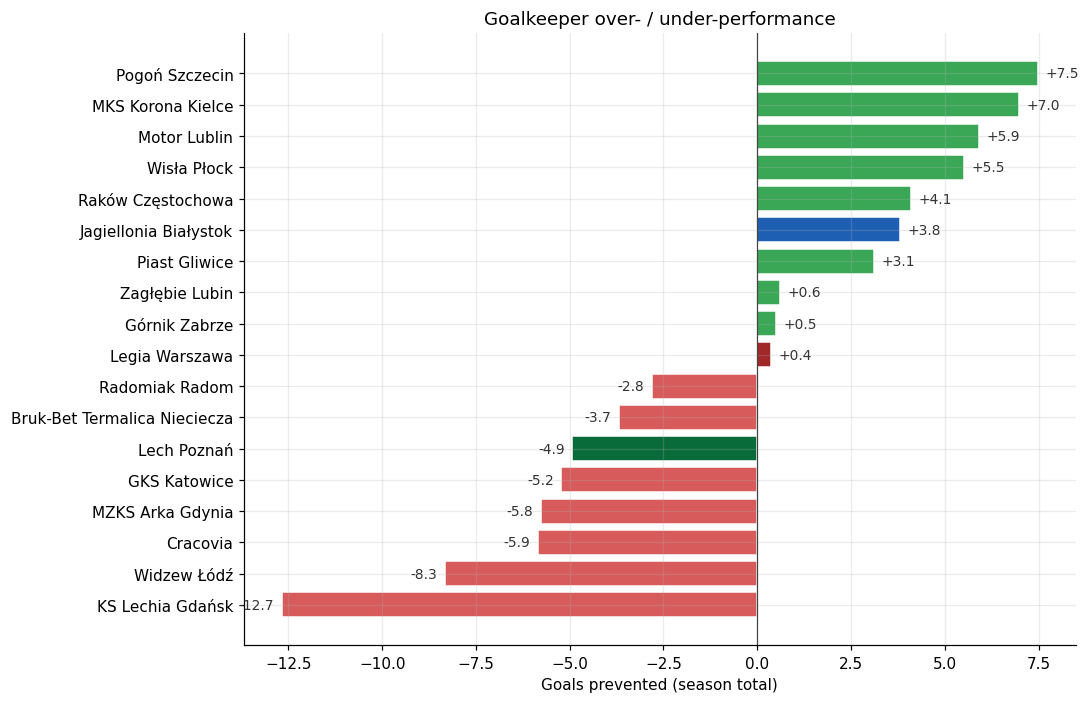

In [24]:
gp = team_match.groupby('team', as_index=False)['goals_prevented'].sum()
gp = gp.sort_values('goals_prevented')

fig, ax = plt.subplots(figsize=(10, 6.5))
bar_colors = [focus_colors.get(t, '#3aa757' if v >= 0 else '#d75b5b')
              for t, v in zip(gp['team'], gp['goals_prevented'])]
ax.barh(gp['team'], gp['goals_prevented'], color=bar_colors, edgecolor='white')
ax.axvline(0, color='#444', lw=0.8)
for i, (t, v) in enumerate(zip(gp['team'], gp['goals_prevented'])):
    ax.text(v + (0.2 if v >= 0 else -0.2), i, f'{v:+.1f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=9, color='#333')
ax.set_xlabel('Goals prevented (season total)')
ax.set_title('Goalkeeper over- / under-performance')
plt.tight_layout()
plt.savefig(f'{FIG}/06_goalkeeper.png')
plt.show()

## 7. Goal sources - open play vs set-piece

Share of season xG by situation per team. Sorted by set-piece dependency.

In [25]:
print(shots['situation'].value_counts())

situation
assisted              3765
corner                1423
regular               1179
set-piece              629
fast-break             590
throw-in-set-piece     524
free-kick              234
penalty                 88
Name: count, dtype: int64


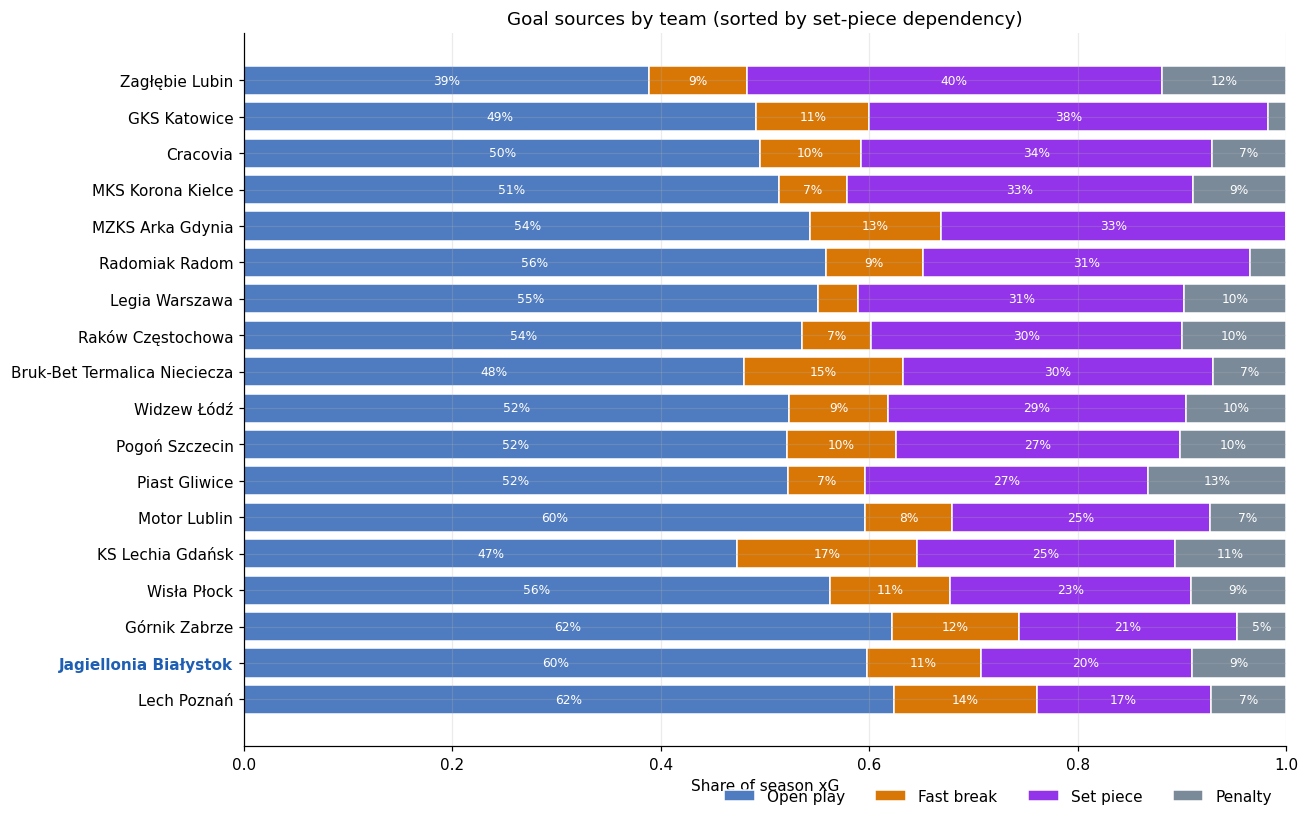

bucket                        Set piece  set_piece_pct
team                                                  
Widzew Łódź                    0.286437           28.6
Bruk-Bet Termalica Nieciecza   0.298077           29.8
Raków Częstochowa              0.298315           29.8
Legia Warszawa                 0.312659           31.3
Radomiak Radom                 0.313962           31.4
MZKS Arka Gdynia               0.331127           33.1
MKS Korona Kielce              0.331700           33.2
Cracovia                       0.336755           33.7
GKS Katowice                   0.383082           38.3
Zagłębie Lubin                 0.398235           39.8


In [26]:
open_play = {'assisted', 'regular'}
set_piece = {'corner', 'set-piece', 'free-kick', 'throw-in-set-piece'}
fast_break = {'fast-break'}
penalty_sit = {'penalty'}

def bucket(s):
    if s in open_play: return 'Open play'
    if s in set_piece: return 'Set piece'
    if s in fast_break: return 'Fast break'
    if s in penalty_sit: return 'Penalty'
    return 'Other'

shots['bucket'] = shots['situation'].map(bucket)

src = (shots.groupby(['team', 'bucket'])['xg'].sum()
       .unstack(fill_value=0))
src_share = src.div(src.sum(axis=1), axis=0)

src_share = src_share.sort_values('Set piece', ascending=True)

order = ['Open play', 'Fast break', 'Set piece', 'Penalty']
src_share = src_share[order]

palette = {
    'Open play': '#4f7cc0',
    'Fast break': '#d97706',
    'Set piece': '#9333ea',
    'Penalty': '#7a8a99',
}

fig, ax = plt.subplots(figsize=(12, 7.5))
left = np.zeros(len(src_share))
for cat in order:
    vals = src_share[cat].values
    ax.barh(src_share.index, vals, left=left, color=palette[cat],
            edgecolor='white', label=cat)
    for i, v in enumerate(vals):
        if v > 0.04:
            ax.text(left[i] + v / 2, i, f'{v*100:.0f}%',
                    va='center', ha='center', fontsize=8, color='white')
    left += vals

ax.set_xlim(0, 1)
ax.set_xlabel('Share of season xG')
ax.set_title('Goal sources by team (sorted by set-piece dependency)')
ax.legend(loc='lower right', frameon=False, ncol=4, bbox_to_anchor=(1, -0.1))

for label in ax.get_yticklabels():
    if label.get_text() == 'Jagiellonia Białystok':
        label.set_color(JAGA)
        label.set_fontweight('bold')

plt.tight_layout()
plt.savefig(f'{FIG}/07_goal_sources.png')
plt.show()

print(src_share.assign(set_piece_pct=(src_share['Set piece']*100).round(1))[['Set piece', 'set_piece_pct']].tail(10))

## 8. Shot maps - top 4 by season xG

Half-pitch view (attacking direction left to right). Each circle is one shot,
size scaled by xG, filled circles are goals, hollow circles are non-goals.

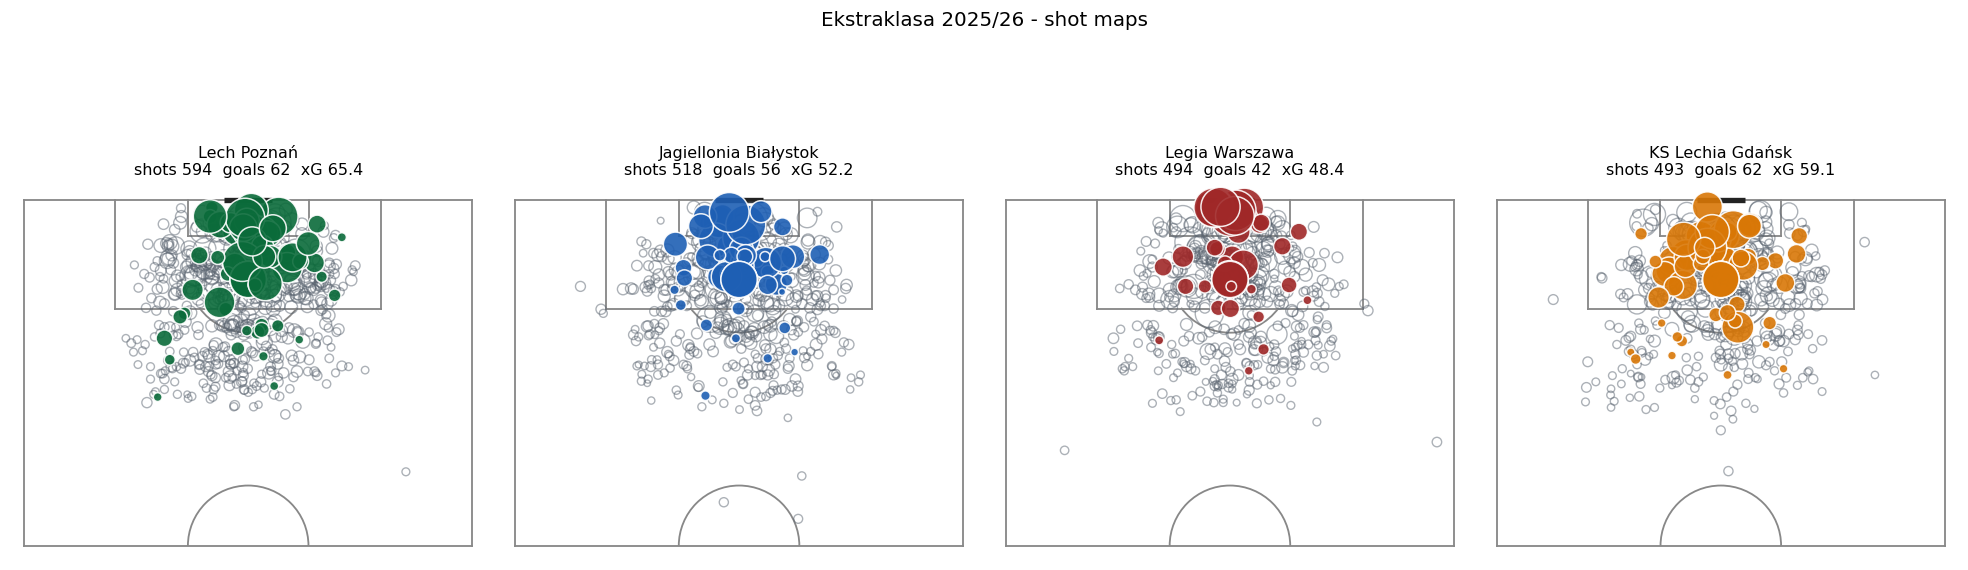

In [32]:
def draw_vpitch(ax):
    ax.set_xlim(-2, 70)
    ax.set_ylim(-2, 55)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)
    line = dict(color='#888', lw=1.2)
    ax.plot([0, 68], [0, 0], **line)
    ax.plot([0, 68], [52.5, 52.5], **line)
    ax.plot([0, 0], [0, 52.5], **line)
    ax.plot([68, 68], [0, 52.5], **line)
    ax.plot([13.84, 54.16], [36, 36], **line)
    ax.plot([13.84, 13.84], [36, 52.5], **line)
    ax.plot([54.16, 54.16], [36, 52.5], **line)
    ax.plot([24.84, 43.16], [47, 47], **line)
    ax.plot([24.84, 24.84], [47, 52.5], **line)
    ax.plot([43.16, 43.16], [47, 52.5], **line)
    ax.scatter([34], [41.5], s=12, c='#888', zorder=2)
    arc = plt.matplotlib.patches.Arc((34, 41.5), 18.3, 18.3, angle=0, theta1=216, theta2=324, color='#888', lw=1.2)
    ax.add_patch(arc)
    cc = plt.matplotlib.patches.Arc((34, 0), 18.3, 18.3, angle=0, theta1=0, theta2=180, color='#888', lw=1.2)
    ax.add_patch(cc)
    ax.plot([30.34, 37.66], [52.5, 52.5], color='#222', lw=3.5, solid_capstyle='butt', zorder=3)

teams_to_show = ['Lech Poznań', 'Jagiellonia Białystok', 'Legia Warszawa', 'KS Lechia Gdańsk']
team_color = {
    'Lech Poznań': LECH,
    'Jagiellonia Białystok': JAGA,
    'Legia Warszawa': LEGIA,
    'KS Lechia Gdańsk': '#d97706',
}

fig, axes = plt.subplots(1, 4, figsize=(18, 6))
for ax, team in zip(axes, teams_to_show):
    draw_vpitch(ax)
    s = shots[shots['team'] == team].copy()
    s['pitch_x'] = s['y'] * 0.68
    s['pitch_y'] = (50 - s['x']) * 1.05
    goals = s[s['is_goal']]
    misses = s[~s['is_goal']]
    ax.scatter(misses['pitch_x'], misses['pitch_y'],
               s=misses['xg'] * 700 + 15, facecolors='none', edgecolors='#5a6470',
               linewidth=0.9, alpha=0.5, zorder=4)
    ax.scatter(goals['pitch_x'], goals['pitch_y'],
               s=goals['xg'] * 700 + 15, c=team_color[team],
               edgecolor='white', linewidth=1.0, alpha=0.9, zorder=5)
    total_xg = s['xg'].sum()
    total_g = int(s['is_goal'].sum())
    ax.set_title(f'{team}\nshots {len(s)}  goals {total_g}  xG {total_xg:.1f}',
                 fontsize=10.5, pad=6)

plt.suptitle('Ekstraklasa 2025/26 - shot maps', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG}/08_shot_maps.png')
plt.show()

## 9. Underlying form - rolling 5-match xG and xGA

Rolling 5-match average of xG created and xGA conceded per matchweek.
Shows the trend underneath the actual results.

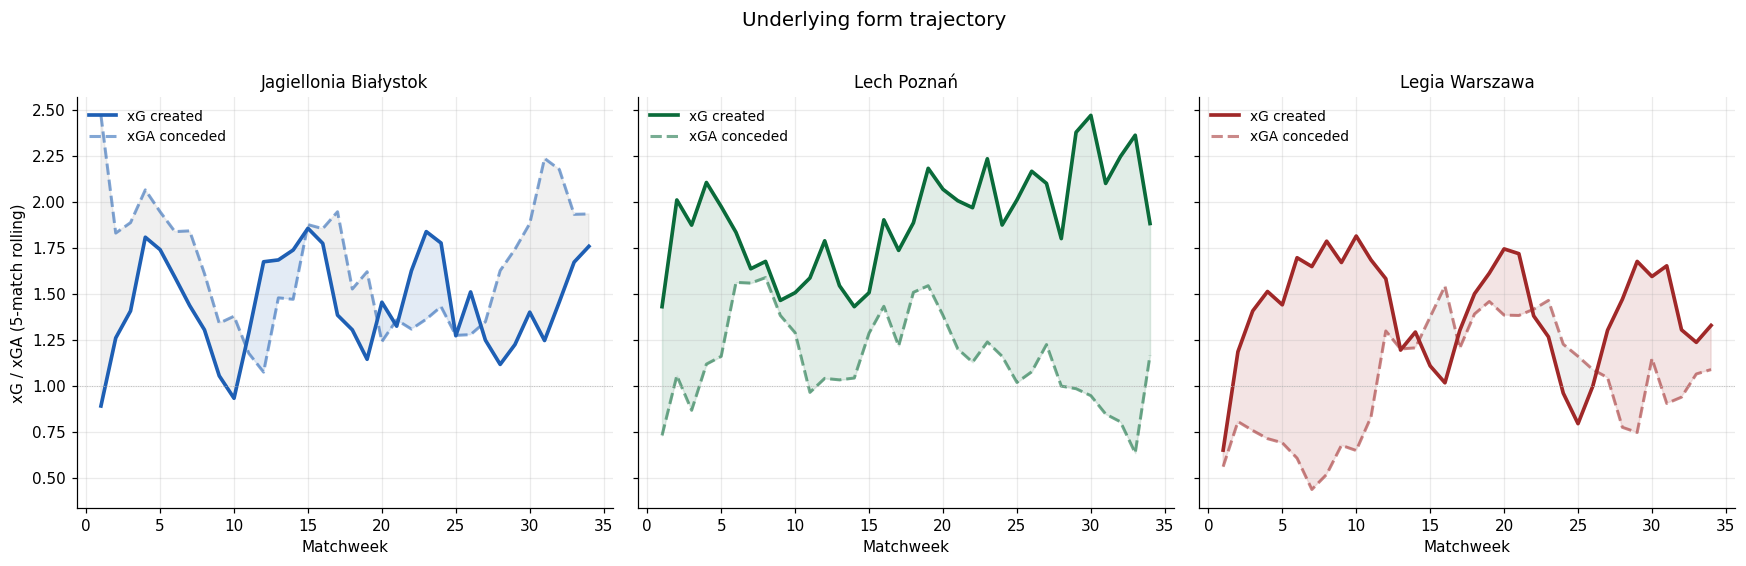

In [33]:
focus = ['Jagiellonia Białystok', 'Lech Poznań', 'Legia Warszawa']
colors = {
    'Jagiellonia Białystok': JAGA,
    'Lech Poznań': LECH,
    'Legia Warszawa': LEGIA,
}

form = team_match[team_match['team'].isin(focus)].copy()
form = form.sort_values(['team', 'round'])
form['roll_xg'] = form.groupby('team')['xg'].transform(lambda s: s.rolling(5, min_periods=1).mean())
form['roll_xga'] = form.groupby('team')['xga'].transform(lambda s: s.rolling(5, min_periods=1).mean())

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, team in zip(axes, focus):
    sub = form[form['team'] == team]
    c = colors[team]
    ax.plot(sub['round'], sub['roll_xg'], color=c, lw=2.4, label='xG created')
    ax.plot(sub['round'], sub['roll_xga'], color=c, lw=2, ls='--', alpha=0.55, label='xGA conceded')
    ax.fill_between(sub['round'], sub['roll_xg'], sub['roll_xga'],
                    where=sub['roll_xg'] >= sub['roll_xga'],
                    color=c, alpha=0.12, interpolate=True)
    ax.fill_between(sub['round'], sub['roll_xg'], sub['roll_xga'],
                    where=sub['roll_xg'] < sub['roll_xga'],
                    color='#888', alpha=0.12, interpolate=True)
    ax.set_title(team, fontsize=11)
    ax.set_xlabel('Matchweek')
    ax.legend(loc='upper left', frameon=False, fontsize=9)
    ax.axhline(1.0, color='#bbb', lw=0.6, ls=':')

axes[0].set_ylabel('xG / xGA (5-match rolling)')
plt.suptitle('Underlying form trajectory', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIG}/09_rolling_xg.png')
plt.show()

## 10. Position over the season

League position by matchweek for the three focus clubs. Compare to the
underlying form in section 9 to see where actual results diverged from
the xG story.

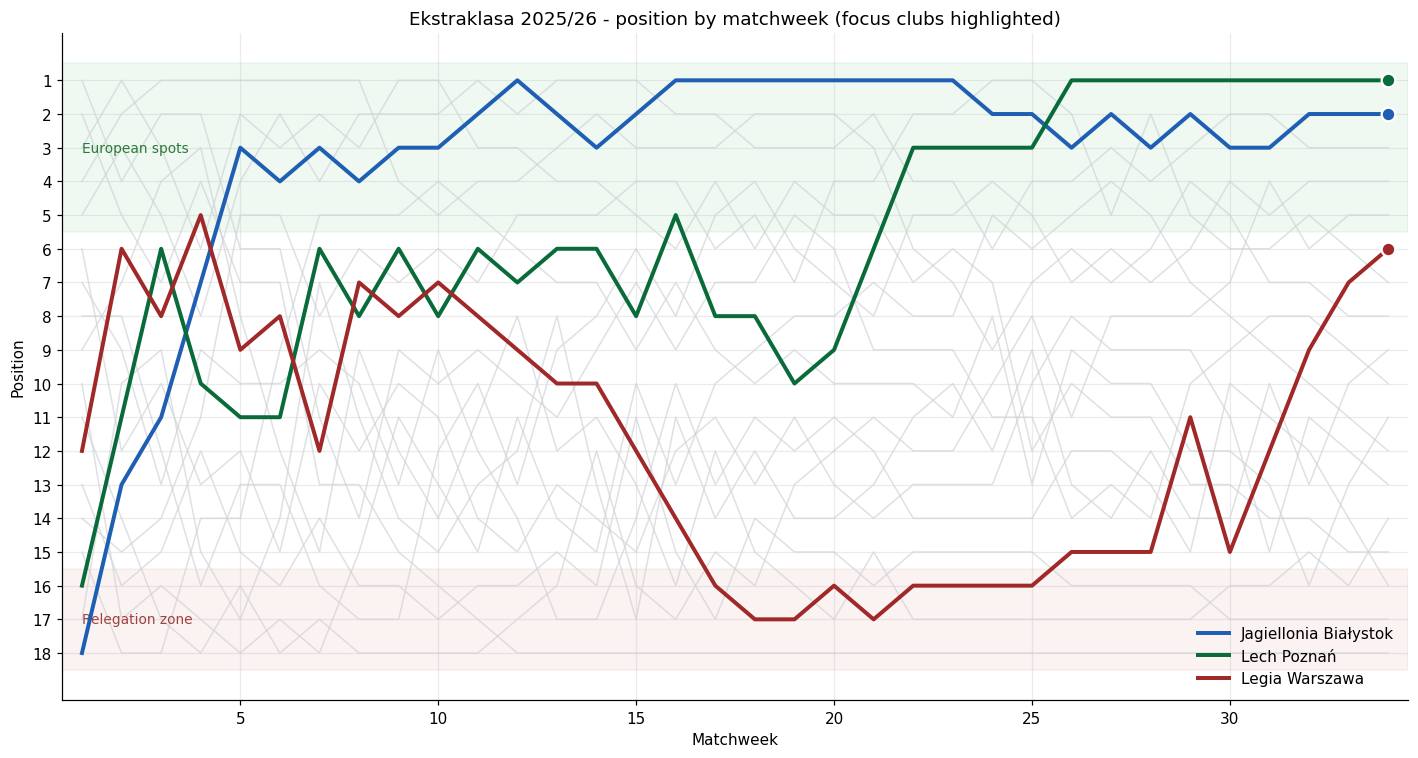

In [47]:
all_rounds = sorted(team_match['round'].unique())
pos_records = []
for r in all_rounds:
    sub = team_match[team_match['round'] <= r]
    t = sub.groupby('team').agg(pts=('pts', 'sum'), gf=('gf', 'sum'), ga=('ga', 'sum')).reset_index()
    t['gd'] = t['gf'] - t['ga']
    t = t.sort_values(['pts', 'gd', 'gf'], ascending=[False, False, False]).reset_index(drop=True)
    t['pos'] = t.index + 1
    t['round'] = r
    pos_records.append(t[['round', 'team', 'pos']])

pos_df = pd.concat(pos_records, ignore_index=True)

fig, ax = plt.subplots(figsize=(13, 7))

for team in pos_df['team'].unique():
    sub = pos_df[pos_df['team'] == team]
    if team in ['Jagiellonia Białystok', 'Lech Poznań', 'Legia Warszawa']:
        continue
    ax.plot(sub['round'], sub['pos'], color='#d0d4d8', lw=1, alpha=0.7)

for team, color in [('Jagiellonia Białystok', JAGA),
                    ('Lech Poznań', LECH),
                    ('Legia Warszawa', LEGIA)]:
    sub = pos_df[pos_df['team'] == team]
    ax.plot(sub['round'], sub['pos'], color=color, lw=2.6, label=team, zorder=5)
    ax.scatter(sub['round'].iloc[-1], sub['pos'].iloc[-1], color=color, s=80, zorder=6, edgecolor='white', linewidth=1.5)

ax.axhspan(15.5, 18.5, color='#d75b5b', alpha=0.08, zorder=0)
ax.text(1, 17, 'Relegation zone', fontsize=9, color='#a04040', va='center')
ax.axhspan(0.5, 5.5, color='#3aa757', alpha=0.08, zorder=0)
ax.text(1, 3, 'European spots', fontsize=9, color='#2a7a3a', va='center')

ax.invert_yaxis()
ax.set_yticks(range(1, 19))
ax.set_xlim(0.5, 34.5)
ax.set_xlabel('Matchweek')
ax.set_ylabel('Position')
ax.set_title('Ekstraklasa 2025/26 - position by matchweek (focus clubs highlighted)')
ax.legend(loc='lower right', frameon=False)
plt.tight_layout()
plt.savefig(f'{FIG}/10_bump_chart.png')
plt.show()

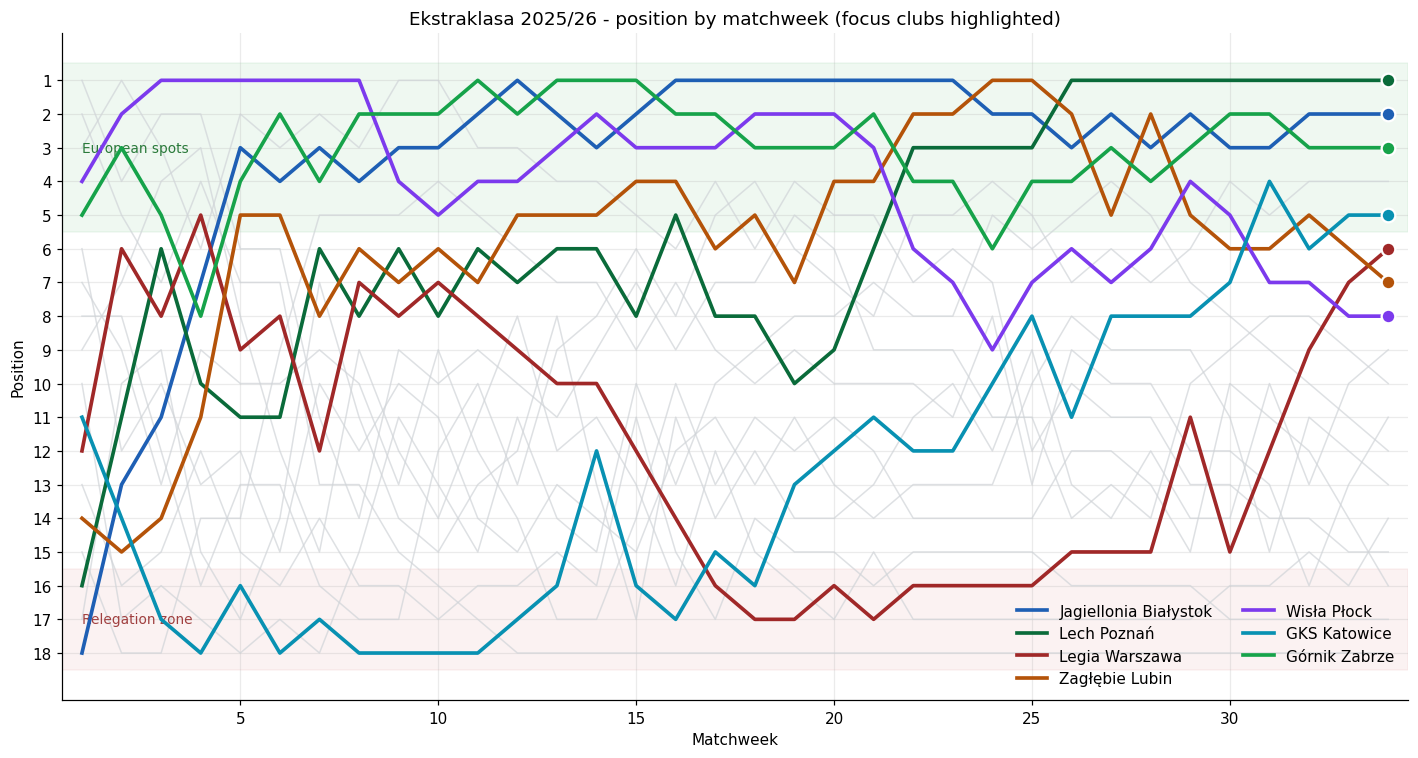

In [49]:
all_rounds = sorted(team_match['round'].unique())
pos_records = []
for r in all_rounds:
    sub = team_match[team_match['round'] <= r]
    t = sub.groupby('team').agg(pts=('pts', 'sum'), gf=('gf', 'sum'), ga=('ga', 'sum')).reset_index()
    t['gd'] = t['gf'] - t['ga']
    t = t.sort_values(['pts', 'gd', 'gf'], ascending=[False, False, False]).reset_index(drop=True)
    t['pos'] = t.index + 1
    t['round'] = r
    pos_records.append(t[['round', 'team', 'pos']])

pos_df = pd.concat(pos_records, ignore_index=True)

highlight = {
    'Jagiellonia Białystok': JAGA,
    'Lech Poznań': LECH,
    'Legia Warszawa': LEGIA,
    'Zagłębie Lubin': '#b45309',
    'Wisła Płock': '#7c3aed',
    'GKS Katowice': '#0891b2',
    'Górnik Zabrze': '#16a34a',
}

fig, ax = plt.subplots(figsize=(13, 7))

for team in pos_df['team'].unique():
    if team in highlight:
        continue
    sub = pos_df[pos_df['team'] == team]
    ax.plot(sub['round'], sub['pos'], color='#d0d4d8', lw=1, alpha=0.7)

for team, color in highlight.items():
    sub = pos_df[pos_df['team'] == team]
    ax.plot(sub['round'], sub['pos'], color=color, lw=2.4, label=team, zorder=5)
    ax.scatter(sub['round'].iloc[-1], sub['pos'].iloc[-1], color=color, s=80,
               zorder=6, edgecolor='white', linewidth=1.5)

ax.axhspan(15.5, 18.5, color='#d75b5b', alpha=0.08, zorder=0)
ax.text(1, 17, 'Relegation zone', fontsize=9, color='#a04040', va='center')
ax.axhspan(0.5, 5.5, color='#3aa757', alpha=0.08, zorder=0)
ax.text(1, 3, 'European spots', fontsize=9, color='#2a7a3a', va='center')

ax.invert_yaxis()
ax.set_yticks(range(1, 19))
ax.set_xlim(0.5, 34.5)
ax.set_xlabel('Matchweek')
ax.set_ylabel('Position')
ax.set_title('Ekstraklasa 2025/26 - position by matchweek (focus clubs highlighted)')
ax.legend(loc='lower right', frameon=False, ncol=2)
plt.tight_layout()
plt.savefig(f'{FIG}/10_bump_chart.png')
plt.show()

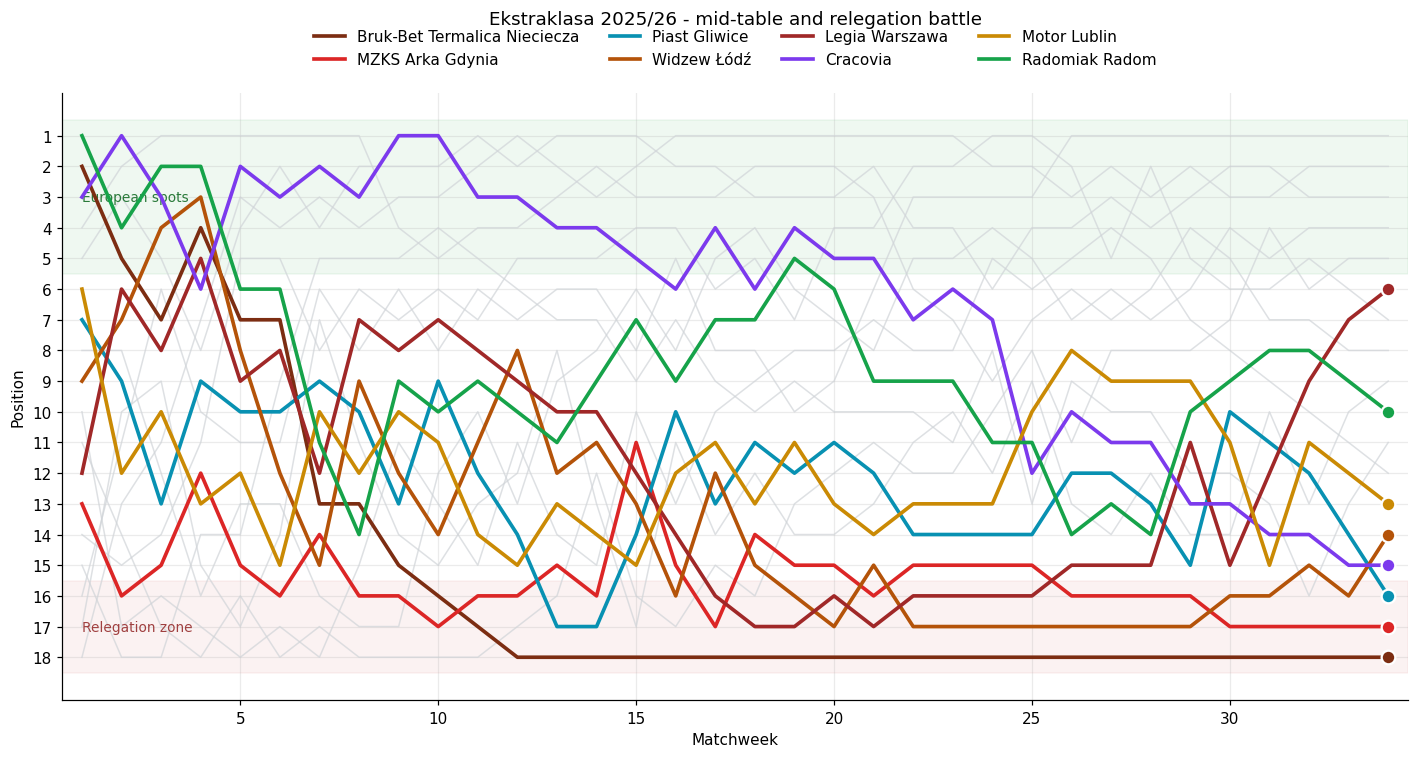

In [51]:
highlight = {
    'Bruk-Bet Termalica Nieciecza': '#7c2d12',
    'MZKS Arka Gdynia': '#dc2626',
    'Piast Gliwice': '#0891b2',
    'Widzew Łódź': '#b45309',
    'Legia Warszawa': LEGIA,
    'Cracovia': '#7c3aed',
    'Motor Lublin': '#ca8a04',
    'Radomiak Radom': '#16a34a',
}

fig, ax = plt.subplots(figsize=(13, 7))

for team in pos_df['team'].unique():
    if team in highlight:
        continue
    sub = pos_df[pos_df['team'] == team]
    ax.plot(sub['round'], sub['pos'], color='#d0d4d8', lw=1, alpha=0.7)

for team, color in highlight.items():
    sub = pos_df[pos_df['team'] == team]
    ax.plot(sub['round'], sub['pos'], color=color, lw=2.4, label=team, zorder=5)
    ax.scatter(sub['round'].iloc[-1], sub['pos'].iloc[-1], color=color, s=80,
               zorder=6, edgecolor='white', linewidth=1.5)

ax.axhspan(15.5, 18.5, color='#d75b5b', alpha=0.08, zorder=0)
ax.text(1, 17, 'Relegation zone', fontsize=9, color='#a04040', va='center')
ax.axhspan(0.5, 5.5, color='#3aa757', alpha=0.08, zorder=0)
ax.text(1, 3, 'European spots', fontsize=9, color='#2a7a3a', va='center')

ax.invert_yaxis()
ax.set_yticks(range(1, 19))
ax.set_xlim(0.5, 34.5)
ax.set_xlabel('Matchweek')
ax.set_ylabel('Position')
ax.set_title('Ekstraklasa 2025/26 - mid-table and relegation battle', pad=45)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), frameon=False, ncol=4)
plt.tight_layout()
plt.savefig(f'{FIG}/10b_bump_chart_bottom.png')
plt.show()